<a href="https://colab.research.google.com/github/Shloka-16/deepfake-detection/blob/main/training_exploration_reinteration_kristine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet-50 Training Pipeline

**AI4ALL Team 9C — Synthetic Sight**

This notebook contains the final training and evaluation pipeline for our Synthetic Sight project. The goal is to classify face images as **Real (0)** or **Fake (1)** using a pretrained ResNet-50 model. In this project, **Fake (1)** is the positive class for precision, recall, F1 score, ROC-AUC, and PR-AUC.

## Notebook overview

This notebook is designed to run from top to bottom in Google Colab and provides a repeatable workflow for:

- setting up the Colab environment and dataset access
- configuring the training run
- building balanced training and validation samples
- training a ResNet-50 model in two stages
- selecting the best validation threshold
- saving the best checkpoint and evaluation artifacts
- optionally evaluating the locked test split

The model is trained in two stages:

1. Train the classifier head while the pretrained backbone stays frozen.
2. Fine-tune `layer4` together with the classifier head.

## Before running

1. Set the Colab runtime to **GPU**.
2. Add the Kaggle token to **Colab Secrets** as `KAGGLE_API_TOKEN`.
3. Review the configuration cell, especially the output paths and run flags.
4. Run all cells from top to bottom.

Keep `RUN_TEST_EVALUATION = False` during development. Change it to `True` only for the final test run after the model and validation threshold are locked.

## Decision rule

The model outputs one logit, `z`, for each image. The predicted probability that an image is fake is:

$$
P(\text{Fake}) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

An image is classified as **Fake** when:

$$
P(\text{Fake}) \geq \text{decision threshold}
$$

The decision threshold is selected on the validation set and then reused for final test evaluation.

> **Repository note**
>
> This is the final executed training notebook retained for reproducibility. It records the run used for the final presentation: seed 13, two-stage ResNet-50 transfer learning, validation-selected decision threshold `0.51`, and the locked 20,000-image test evaluation. The project package intentionally does **not** include a legacy checkpoint from the original archive because that artifact did not match this final run. See `models/README.md` and `docs/repository-review.md`.

## 1. Install the Kaggle command-line package

Colab already includes the core scientific and PyTorch packages. The Kaggle package is installed for dataset download.

In [ ]:
!pip install -q kaggle

## 2. Imports and Colab environment

This section loads the libraries used in the notebook and prepares the Google Colab environment. Google Drive is mounted here so saved outputs such as checkpoints, metrics, and plots can be written to a consistent location.

In [ ]:
import hashlib
import os
import pickle
import random
import subprocess
import sys
import warnings
from pathlib import Path

# Configure deterministic CUDA behavior before the first CUDA operation.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

try:
    from google.colab import drive, userdata
except ImportError as exc:
    raise RuntimeError(
        "This notebook is configured for Google Colab. Open it in Colab "
        "or replace the Colab-specific Drive and Secrets setup."
    ) from exc

drive.mount("/content/drive", force_remount=False)

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python: 3.12.13
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


## 3. Project configuration

This section collects the main settings used throughout the notebook so the training pipeline is easy to review and rerun. It includes dataset paths, output locations, label definitions, sampling choices, model hyperparameters, and run-control flags.

A few settings are especially important to check before running:

- `PROJECT_OUTPUT_DIRECTORY`, which controls where checkpoints, metrics, and plots are saved
- `RUN_TRAINING`, which determines whether the notebook trains a new model or loads an existing checkpoint
- `RUN_TEST_EVALUATION`, which controls whether the final test split is evaluated
- `FORCE_RERUN_TEST`, which should remain `False` unless there is a clear reason to repeat the final test evaluation

The training schedule is also defined here. The model first trains the new classifier head, then begins fine-tuning ResNet-50 `layer4`, with early-stopping patience reset at the start of fine-tuning so training does not stop before that stage begins.

In [ ]:
# -----------------------------
# Dataset and output locations
# -----------------------------

KAGGLE_DATASET_NAME = "xhlulu/140k-real-and-fake-faces"
DATASET_DOWNLOAD_DIRECTORY = Path("/content")
EXPECTED_DATASET_ROOT = DATASET_DOWNLOAD_DIRECTORY / "real_vs_fake" / "real-vs-fake"

PROJECT_OUTPUT_DIRECTORY = Path(
    "/content/drive/MyDrive/deepfake_detection_checkpoints"
)
PROJECT_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = PROJECT_OUTPUT_DIRECTORY / "best_resnet50.pth"
HISTORY_PATH = PROJECT_OUTPUT_DIRECTORY / "resnet50_training_history.csv"
SAMPLE_MANIFEST_PATH = PROJECT_OUTPUT_DIRECTORY / "resnet50_sample_manifest.csv"

VALIDATION_METRICS_PATH = PROJECT_OUTPUT_DIRECTORY / "resnet50_validation_metrics.csv"
VALIDATION_PREDICTIONS_PATH = PROJECT_OUTPUT_DIRECTORY / "resnet50_validation_predictions.npz"

TEST_METRICS_PATH = PROJECT_OUTPUT_DIRECTORY / "resnet50_final_test_metrics.csv"
TEST_PREDICTIONS_PATH = PROJECT_OUTPUT_DIRECTORY / "resnet50_final_test_predictions.npz"

# -----------------------------
# Reproducibility and labels
# -----------------------------

SEED = 13

REAL_LABEL = 0
FAKE_LABEL = 1
CLASS_NAMES = ["Real", "Fake"]

# -----------------------------
# Data sampling and loading
# -----------------------------

TRAIN_SAMPLES_PER_CLASS = 50_000
VALID_SAMPLES_PER_CLASS = 10_000

BATCH_SIZE = 32
NUM_WORKERS = 2
RESNET_IMAGE_SIZE = (224, 224)

# ImageNet normalization used by the pretrained ResNet-50 weights.
RESNET_NORMALIZE_MEAN = [0.485, 0.456, 0.406]
RESNET_NORMALIZE_STD = [0.229, 0.224, 0.225]

# -----------------------------
# Model and optimization
# -----------------------------

MAX_EPOCHS = 15
HEAD_ONLY_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 3

HEAD_HIDDEN_UNITS = 256
HEAD_DROPOUT = 0.30

HEAD_LEARNING_RATE = 5e-4
LAYER4_LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

MONITOR_METRIC = "Fake F1"
SUPPORTED_MONITOR_METRICS = {
    "Accuracy",
    "Fake precision",
    "Fake recall",
    "Fake F1",
    "Real F1",
    "Macro F1",
    "Weighted F1",
    "ROC-AUC",
    "PR-AUC",
}

# Search 0.05 through 0.95 in 0.01 increments.
THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)

# -----------------------------
# Run controls
# -----------------------------

RUN_TRAINING = True
RUN_TEST_EVALUATION = True
FORCE_RERUN_TEST = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

if DEVICE.type != "cuda":
    warnings.warn(
        "No GPU was detected. The notebook can run on CPU, but ResNet-50 "
        "training will be substantially slower."
    )

print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")
print(f"Label convention: Real={REAL_LABEL}, Fake={FAKE_LABEL}")
print(f"Output directory: {PROJECT_OUTPUT_DIRECTORY}")
print(f"Run training: {RUN_TRAINING}")
print(f"Run final test: {RUN_TEST_EVALUATION}")

Device: cuda
Seed: 13
Label convention: Real=0, Fake=1
Output directory: /content/drive/MyDrive/deepfake_detection_checkpoints
Run training: True
Run final test: True


## 4. Reproducibility, loading, sampling, and metric helpers

This section defines helper functions that are used throughout the rest of the notebook. These functions support reproducibility, data loading, balanced sampling, checkpoint handling, threshold selection, and evaluation.

The reproducibility helpers set random seeds for Python, NumPy, PyTorch, and DataLoader workers so runs are as consistent as possible across training sessions. Other helpers are used to safely load saved checkpoints, create balanced real and fake samples, choose the best validation threshold, and calculate classification metrics.

In this project, **Fake (`1`)** is treated as the positive class when computing precision, recall, F1 score, ROC-AUC, and PR-AUC.

In [ ]:
def seed_everything(seed=SEED):
    """
    Seed Python, NumPy, and PyTorch.

    Deterministic algorithms improve repeatability. Exact bit-for-bit equality
    can still depend on the Colab hardware, PyTorch version, and CUDA version.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)


def seed_data_loader_worker(worker_id):
    """Give each DataLoader worker a deterministic Python and NumPy seed."""
    del worker_id  # The seed already encodes the worker ID.
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_seeded_data_loader(
    dataset,
    *,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
):
    """
    Create a reproducible DataLoader.

    A generator is supplied even when shuffle=False so worker seeds remain
    repeatable for every loader.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=NUM_WORKERS,
        worker_init_fn=seed_data_loader_worker,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )


def load_trusted_checkpoint(checkpoint_path, device=DEVICE):
    """
    Load a checkpoint created by this notebook.

    `weights_only=True` is used when supported so loading is restricted to
    tensors and basic data structures. The fallback supports older PyTorch
    versions that do not expose the argument.
    """
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    try:
        return torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True,
        )
    except TypeError:
        # Older PyTorch versions do not accept the weights_only argument.
        return torch.load(checkpoint_path, map_location=device)
    except (pickle.UnpicklingError, RuntimeError) as exc:
        warnings.warn(
            "Safe checkpoint loading failed, which can occur with a checkpoint "
            "created by the earlier notebook format. Falling back to full "
            "loading because this helper is only for checkpoints you created "
            "and trust. Never use this fallback for an untrusted file."
        )
        try:
            return torch.load(
                checkpoint_path,
                map_location=device,
                weights_only=False,
            )
        except TypeError:
            raise exc


def file_sha256(file_path, chunk_size=1024 * 1024):
    """Return a SHA-256 fingerprint for an artifact file."""
    digest = hashlib.sha256()
    with Path(file_path).open("rb") as file_handle:
        while chunk := file_handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def make_balanced_sample(
    real_paths,
    fake_paths,
    *,
    samples_per_class,
    seed=SEED,
):
    """Select, label, combine, and reproducibly shuffle equal class samples."""
    real_paths = list(real_paths)
    fake_paths = list(fake_paths)

    if samples_per_class <= 0:
        raise ValueError("samples_per_class must be greater than zero.")

    if len(real_paths) < samples_per_class:
        raise ValueError(
            f"Requested {samples_per_class:,} real images, but only "
            f"{len(real_paths):,} are available."
        )

    if len(fake_paths) < samples_per_class:
        raise ValueError(
            f"Requested {samples_per_class:,} fake images, but only "
            f"{len(fake_paths):,} are available."
        )

    python_rng = random.Random(seed)
    selected_real_paths = python_rng.sample(real_paths, samples_per_class)
    selected_fake_paths = python_rng.sample(fake_paths, samples_per_class)

    selected_paths = selected_real_paths + selected_fake_paths
    selected_targets = np.array(
        [REAL_LABEL] * samples_per_class
        + [FAKE_LABEL] * samples_per_class,
        dtype=np.int64,
    )

    shuffle_order = np.random.default_rng(seed).permutation(len(selected_paths))
    shuffled_paths = [selected_paths[index] for index in shuffle_order]
    shuffled_targets = selected_targets[shuffle_order]

    return shuffled_paths, shuffled_targets


def find_best_threshold(
    true_targets,
    predicted_probabilities,
    thresholds=THRESHOLD_GRID,
):
    """
    Select the threshold with the highest Fake F1.

    Ties are resolved by choosing the threshold closest to 0.50, which avoids
    an arbitrary preference for the first (lowest) threshold in the grid.
    """
    true_targets = np.asarray(true_targets, dtype=np.int64)
    predicted_probabilities = np.asarray(
        predicted_probabilities,
        dtype=np.float64,
    )

    candidates = []
    for threshold in thresholds:
        predictions = (
            predicted_probabilities >= float(threshold)
        ).astype(np.int64)

        fake_f1 = f1_score(
            true_targets,
            predictions,
            pos_label=FAKE_LABEL,
            zero_division=0,
        )
        candidates.append(
            (
                float(fake_f1),
                -abs(float(threshold) - 0.50),
                float(threshold),
            )
        )

    best_fake_f1, _, best_threshold = max(candidates)
    return float(best_threshold), float(best_fake_f1)


def calculate_classification_metrics(
    *,
    experiment_name,
    evaluation_split,
    true_targets,
    predicted_targets,
    predicted_probabilities=None,
    threshold=0.50,
):
    """Return a plain-Python metrics dictionary suitable for CSV/checkpoint use."""
    true_targets = np.asarray(true_targets, dtype=np.int64)
    predicted_targets = np.asarray(predicted_targets, dtype=np.int64)

    metrics = {
        "Experiment": str(experiment_name),
        "Evaluation split": str(evaluation_split),
        "Images": int(len(true_targets)),
        "Accuracy": float(accuracy_score(true_targets, predicted_targets)),
        "Fake precision": float(
            precision_score(
                true_targets,
                predicted_targets,
                pos_label=FAKE_LABEL,
                zero_division=0,
            )
        ),
        "Fake recall": float(
            recall_score(
                true_targets,
                predicted_targets,
                pos_label=FAKE_LABEL,
                zero_division=0,
            )
        ),
        "Fake F1": float(
            f1_score(
                true_targets,
                predicted_targets,
                pos_label=FAKE_LABEL,
                zero_division=0,
            )
        ),
        "Real F1": float(
            f1_score(
                true_targets,
                predicted_targets,
                pos_label=REAL_LABEL,
                zero_division=0,
            )
        ),
        "Macro F1": float(
            f1_score(
                true_targets,
                predicted_targets,
                average="macro",
                zero_division=0,
            )
        ),
        "Weighted F1": float(
            f1_score(
                true_targets,
                predicted_targets,
                average="weighted",
                zero_division=0,
            )
        ),
        "Decision threshold": float(threshold),
    }

    if predicted_probabilities is None:
        metrics["ROC-AUC"] = np.nan
        metrics["PR-AUC"] = np.nan
    else:
        predicted_probabilities = np.asarray(
            predicted_probabilities,
            dtype=np.float64,
        )
        metrics["ROC-AUC"] = float(
            roc_auc_score(true_targets, predicted_probabilities)
        )
        metrics["PR-AUC"] = float(
            average_precision_score(
                true_targets,
                predicted_probabilities,
                pos_label=FAKE_LABEL,
            )
        )

    return metrics


seed_everything()

## 5. Download and locate the Kaggle dataset

This section downloads the dataset from Kaggle if it is not already available in the Colab runtime. The Kaggle access token is read from Colab Secrets, written to the temporary runtime in the format expected by the Kaggle command-line tool, and never printed to the notebook output.

Before downloading, the function checks whether the dataset has already been extracted. After the download step, it verifies that the expected dataset folder structure exists instead of assuming the extraction completed correctly.

In [ ]:
def download_kaggle_dataset(
    *,
    dataset_name=KAGGLE_DATASET_NAME,
    download_directory=DATASET_DOWNLOAD_DIRECTORY,
    expected_root=EXPECTED_DATASET_ROOT,
):
    """Download the dataset when needed and return its verified root path."""
    if expected_root.exists():
        print(f"Dataset already found at: {expected_root}")
        return expected_root

    kaggle_token = userdata.get("KAGGLE_API_TOKEN")
    if not kaggle_token:
        raise ValueError(
            "KAGGLE_API_TOKEN was not found in Colab Secrets. "
            "Add the token, grant notebook access, and run this cell again."
        )

    kaggle_directory = Path.home() / ".kaggle"
    kaggle_directory.mkdir(parents=True, exist_ok=True)

    token_path = kaggle_directory / "access_token"
    token_path.write_text(kaggle_token.strip(), encoding="utf-8")
    token_path.chmod(0o600)

    print(f"Downloading Kaggle dataset: {dataset_name}")
    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            dataset_name,
            "--unzip",
            "-p",
            str(download_directory),
        ],
        check=True,
    )

    if expected_root.exists():
        print(f"Dataset extracted to: {expected_root}")
        return expected_root

    # Fallback search protects against a future change in archive nesting.
    candidate_roots = [
        path
        for path in download_directory.rglob("real-vs-fake")
        if (path / "train").is_dir()
        and (path / "valid").is_dir()
        and (path / "test").is_dir()
    ]

    if len(candidate_roots) == 1:
        print(f"Dataset located at: {candidate_roots[0]}")
        return candidate_roots[0]

    raise FileNotFoundError(
        "The download completed, but the dataset root could not be identified. "
        f"Expected: {expected_root}"
    )


DATASET_ROOT = download_kaggle_dataset()

Dataset already found at: /content/real_vs_fake/real-vs-fake


## 6. Verify split directories and image counts

This section checks that all expected class directories exist and that every image appears in exactly one official split. It lists the real and fake image files in the training, validation, and test folders, confirms that the splits are disjoint, and summarizes the image counts for each split.

Listing the test files here does **not** evaluate the model on them. The test split remains unused for training and validation, and predictions are only computed when the final-test flag is enabled later in the notebook.

In [ ]:
TRAIN_REAL_DIRECTORY = DATASET_ROOT / "train" / "real"
TRAIN_FAKE_DIRECTORY = DATASET_ROOT / "train" / "fake"

VALID_REAL_DIRECTORY = DATASET_ROOT / "valid" / "real"
VALID_FAKE_DIRECTORY = DATASET_ROOT / "valid" / "fake"

TEST_REAL_DIRECTORY = DATASET_ROOT / "test" / "real"
TEST_FAKE_DIRECTORY = DATASET_ROOT / "test" / "fake"

EXPECTED_CLASS_DIRECTORIES = {
    "train/real": TRAIN_REAL_DIRECTORY,
    "train/fake": TRAIN_FAKE_DIRECTORY,
    "valid/real": VALID_REAL_DIRECTORY,
    "valid/fake": VALID_FAKE_DIRECTORY,
    "test/real": TEST_REAL_DIRECTORY,
    "test/fake": TEST_FAKE_DIRECTORY,
}


def list_image_paths(directory):
    """Return sorted JPG/JPEG/PNG files from one class directory."""
    directory = Path(directory)
    if not directory.is_dir():
        raise FileNotFoundError(f"Image directory not found: {directory}")

    image_paths = sorted(
        path
        for path in directory.iterdir()
        if path.is_file()
        and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )

    if not image_paths:
        raise ValueError(f"No supported image files found in: {directory}")

    return image_paths


missing_directories = [
    f"{name}: {path}"
    for name, path in EXPECTED_CLASS_DIRECTORIES.items()
    if not path.is_dir()
]
if missing_directories:
    raise FileNotFoundError(
        "Required dataset directories are missing:\n"
        + "\n".join(missing_directories)
    )

train_real_paths = list_image_paths(TRAIN_REAL_DIRECTORY)
train_fake_paths = list_image_paths(TRAIN_FAKE_DIRECTORY)

valid_real_paths = list_image_paths(VALID_REAL_DIRECTORY)
valid_fake_paths = list_image_paths(VALID_FAKE_DIRECTORY)

test_real_paths = list_image_paths(TEST_REAL_DIRECTORY)
test_fake_paths = list_image_paths(TEST_FAKE_DIRECTORY)

split_path_sets = {
    "Train": set(train_real_paths + train_fake_paths),
    "Validation": set(valid_real_paths + valid_fake_paths),
    "Test": set(test_real_paths + test_fake_paths),
}

assert split_path_sets["Train"].isdisjoint(split_path_sets["Validation"])
assert split_path_sets["Train"].isdisjoint(split_path_sets["Test"])
assert split_path_sets["Validation"].isdisjoint(split_path_sets["Test"])

dataset_count_table = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Real": len(train_real_paths),
            "Fake": len(train_fake_paths),
            "Total images": len(train_real_paths) + len(train_fake_paths),
        },
        {
            "Split": "Validation",
            "Real": len(valid_real_paths),
            "Fake": len(valid_fake_paths),
            "Total images": len(valid_real_paths) + len(valid_fake_paths),
        },
        {
            "Split": "Test",
            "Real": len(test_real_paths),
            "Fake": len(test_fake_paths),
            "Total images": len(test_real_paths) + len(test_fake_paths),
        },
    ]
)

display(dataset_count_table)
print("Verified: official train, validation, and test paths are disjoint.")

,Split,Real,Fake,Total images
0,Train,50000,50000,100000
1,Validation,10000,10000,20000
2,Test,10000,10000,20000


Verified: official train, validation, and test paths are disjoint.


## 7. Build the reproducible balanced train and validation samples

This section creates balanced training and validation samples by selecting the same number of real and fake images from the official dataset splits. The sampling process is reproducible, so the same seed produces the same sampled image sets each time the notebook is run.

The training sample is drawn from the official training folders, and the validation sample is drawn only from the official validation folders. After sampling, the notebook checks that the selected training and validation paths do not overlap and saves a manifest to Google Drive so the exact sampled files and labels are documented.

In [ ]:
project_train_paths, project_train_targets = make_balanced_sample(
    train_real_paths,
    train_fake_paths,
    samples_per_class=TRAIN_SAMPLES_PER_CLASS,
    seed=SEED,
)

project_valid_paths, project_valid_targets = make_balanced_sample(
    valid_real_paths,
    valid_fake_paths,
    samples_per_class=VALID_SAMPLES_PER_CLASS,
    seed=SEED,
)

train_real_count = int((project_train_targets == REAL_LABEL).sum())
train_fake_count = int((project_train_targets == FAKE_LABEL).sum())
valid_real_count = int((project_valid_targets == REAL_LABEL).sum())
valid_fake_count = int((project_valid_targets == FAKE_LABEL).sum())

shared_sample_summary = pd.DataFrame(
    [
        {
            "Split": "Training sample",
            "Real": train_real_count,
            "Fake": train_fake_count,
            "Total images": train_real_count + train_fake_count,
        },
        {
            "Split": "Validation sample",
            "Real": valid_real_count,
            "Fake": valid_fake_count,
            "Total images": valid_real_count + valid_fake_count,
        },
    ]
)

display(shared_sample_summary)

assert set(project_train_paths).isdisjoint(project_valid_paths)
assert len(project_train_paths) == len(project_train_targets)
assert len(project_valid_paths) == len(project_valid_targets)

sample_manifest = pd.concat(
    [
        pd.DataFrame(
            {
                "Split": "Train",
                "Image path": [str(path) for path in project_train_paths],
                "Label": project_train_targets,
            }
        ),
        pd.DataFrame(
            {
                "Split": "Validation",
                "Image path": [str(path) for path in project_valid_paths],
                "Label": project_valid_targets,
            }
        ),
    ],
    ignore_index=True,
)
sample_manifest.to_csv(SAMPLE_MANIFEST_PATH, index=False)

print("Verified: sampled training and validation paths do not overlap.")
print(f"Sample manifest saved to: {SAMPLE_MANIFEST_PATH}")

,Split,Real,Fake,Total images
0,Training sample,50000,50000,100000
1,Validation sample,10000,10000,20000


Verified: sampled training and validation paths do not overlap.
Sample manifest saved to: /content/drive/MyDrive/deepfake_detection_checkpoints/resnet50_sample_manifest.csv


## 8. Dataset class and image transforms

This section defines the custom dataset class used for loading images from file paths and applies the image transforms needed for training and evaluation.

The training transform uses only modest augmentation:
- horizontal flips to reduce sensitivity to left/right orientation
- light brightness, contrast, saturation, and hue changes to improve robustness to ordinary appearance variation

Rotation was removed because it can introduce artificial corners or borders that may become shortcut features instead of meaningful facial cues. The validation and test transforms are deterministic and identical, so evaluation results are not affected by random augmentation.

In [ ]:
class FacePathDataset(Dataset):
    """Load RGB images from paths and return float binary targets."""

    def __init__(self, image_paths, numeric_targets, image_transform):
        if len(image_paths) != len(numeric_targets):
            raise ValueError("Image paths and targets must have equal length.")

        if image_transform is None:
            raise ValueError("image_transform cannot be None.")

        self.image_paths = [Path(path) for path in image_paths]
        self.numeric_targets = np.asarray(
            numeric_targets,
            dtype=np.int64,
        )
        self.image_transform = image_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]

        try:
            with Image.open(image_path) as image:
                rgb_image = image.convert("RGB")
        except Exception as exc:
            raise RuntimeError(
                f"Could not read image at index {index}: {image_path}"
            ) from exc

        transformed_image = self.image_transform(rgb_image)
        numeric_target = torch.tensor(
            self.numeric_targets[index],
            dtype=torch.float32,
        )

        return transformed_image, numeric_target


train_transform = transforms.Compose(
    [
        transforms.Resize(
            RESNET_IMAGE_SIZE,
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=RESNET_NORMALIZE_MEAN,
            std=RESNET_NORMALIZE_STD,
        ),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.Resize(
            RESNET_IMAGE_SIZE,
            interpolation=InterpolationMode.BILINEAR,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=RESNET_NORMALIZE_MEAN,
            std=RESNET_NORMALIZE_STD,
        ),
    ]
)

resnet50_train_dataset = FacePathDataset(
    image_paths=project_train_paths,
    numeric_targets=project_train_targets,
    image_transform=train_transform,
)

resnet50_valid_dataset = FacePathDataset(
    image_paths=project_valid_paths,
    numeric_targets=project_valid_targets,
    image_transform=evaluation_transform,
)

print(f"Training dataset images: {len(resnet50_train_dataset):,}")
print(f"Validation dataset images: {len(resnet50_valid_dataset):,}")

Training dataset images: 100,000
Validation dataset images: 20,000


## 9. Build the ResNet-50 transfer-learning model

This section constructs the transfer-learning model used in the project. The backbone is a ResNet-50 network pretrained on ImageNet, which is initially frozen so its weights are not updated during the first training stage.

The original 1,000-class classification layer is replaced with a binary head:

`Linear(2048 → 256) → BatchNorm1d → ReLU → Dropout(0.30) → Linear(256 → 1)`

The single output from this head is a logit for the Fake class. Later in the notebook, `BCEWithLogitsLoss` is used as the loss function because it combines a numerically stable sigmoid operation with binary cross-entropy for binary classification.

In [ ]:
def build_resnet50_transfer_model(
    device=DEVICE,
    *,
    hidden_units=HEAD_HIDDEN_UNITS,
    dropout=HEAD_DROPOUT,
    use_pretrained_weights=True,
):
    """
    Create a fresh seeded ResNet-50 with a frozen backbone and binary head.

    Pretrained weights are required for a new training run. They can be
    skipped when a complete saved checkpoint will immediately be loaded.
    """
    seed_everything()

    weights = (
        models.ResNet50_Weights.DEFAULT
        if use_pretrained_weights
        else None
    )
    model = models.resnet50(weights=weights)

    for parameter in model.parameters():
        parameter.requires_grad = False

    backbone_output_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(backbone_output_features, hidden_units),
        nn.BatchNorm1d(hidden_units),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_units, 1),
    )

    return model.to(device)


def count_parameters(model):
    """Return total and currently trainable parameter counts."""
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return total_parameters, trainable_parameters


## 10. Training and validation functions

This section defines the functions used to train the model for one epoch, run validation, compute probabilities, and calculate evaluation metrics. The training pipeline has two stages: a head-only stage, where only the new classifier head is updated, and a fine-tuning stage, where `layer4` is unfrozen and trained with a smaller learning rate.

During the head-only stage, the pretrained backbone stays frozen. During fine-tuning, `layer4` is updated while its `BatchNorm2d` running statistics remain fixed for stability, and the classifier head continues to train normally. Loss is averaged by the number of images rather than the number of batches, so the final batch is weighted correctly even when it is smaller than the others.

In [ ]:
def unfreeze_resnet_layer4(model):
    """Enable gradient updates for the final residual stage."""
    for parameter in model.layer4.parameters():
        parameter.requires_grad = True


def set_training_stage_mode(model, *, fine_tune_layer4):
    """
    Set only the intended modules to training mode.

    The full model starts in evaluation mode so frozen backbone BatchNorm
    statistics do not drift. The head always trains. During fine-tuning,
    layer4 trains but its BatchNorm2d modules remain in evaluation mode.
    """
    model.eval()
    model.fc.train()

    if fine_tune_layer4:
        model.layer4.train()
        for module in model.layer4.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()


def build_optimizer(model, *, fine_tune_layer4):
    """Create the optimizer for the current training stage."""
    parameter_groups = []

    if fine_tune_layer4:
        layer4_parameters = [
            parameter
            for parameter in model.layer4.parameters()
            if parameter.requires_grad
        ]
        parameter_groups.append(
            {
                "name": "layer4",
                "params": layer4_parameters,
                "lr": LAYER4_LEARNING_RATE,
            }
        )

    parameter_groups.append(
        {
            "name": "head",
            "params": model.fc.parameters(),
            "lr": HEAD_LEARNING_RATE,
        }
    )

    return torch.optim.Adam(
        parameter_groups,
        weight_decay=WEIGHT_DECAY,
    )


def get_optimizer_learning_rate(optimizer, group_name):
    """Read a named optimizer group's current learning rate."""
    for parameter_group in optimizer.param_groups:
        if parameter_group.get("name") == group_name:
            return float(parameter_group["lr"])
    return np.nan


def run_training_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    *,
    device,
    fine_tune_layer4,
):
    """Run one training epoch and return image-weighted average loss."""
    if len(data_loader.dataset) == 0:
        raise ValueError("Training dataset is empty.")

    set_training_stage_mode(
        model,
        fine_tune_layer4=fine_tune_layer4,
    )

    total_loss = 0.0
    total_images = 0

    for batch_images, batch_targets in data_loader:
        batch_images = batch_images.to(
            device,
            non_blocking=PIN_MEMORY,
        )
        batch_targets = batch_targets.to(
            device,
            non_blocking=PIN_MEMORY,
        ).view(-1, 1)

        optimizer.zero_grad(set_to_none=True)

        logits = model(batch_images)
        loss = loss_function(logits, batch_targets)

        loss.backward()
        optimizer.step()

        batch_size = batch_images.size(0)
        total_loss += float(loss.item()) * batch_size
        total_images += batch_size

    return total_loss / total_images


def run_evaluation_epoch(
    model,
    data_loader,
    loss_function,
    *,
    device,
):
    """Return average loss, true targets, and Fake probabilities."""
    if len(data_loader.dataset) == 0:
        raise ValueError("Evaluation dataset is empty.")

    model.eval()

    total_loss = 0.0
    total_images = 0
    collected_targets = []
    collected_probabilities = []

    with torch.inference_mode():
        for batch_images, batch_targets in data_loader:
            batch_images = batch_images.to(
                device,
                non_blocking=PIN_MEMORY,
            )
            batch_targets = batch_targets.to(
                device,
                non_blocking=PIN_MEMORY,
            ).view(-1, 1)

            logits = model(batch_images)
            loss = loss_function(logits, batch_targets)
            fake_probabilities = torch.sigmoid(logits).view(-1)

            batch_size = batch_images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_images += batch_size

            collected_targets.extend(
                batch_targets.view(-1).cpu().numpy().astype(np.int64)
            )
            collected_probabilities.extend(
                fake_probabilities.cpu().numpy().astype(np.float64)
            )

    return (
        total_loss / total_images,
        np.asarray(collected_targets, dtype=np.int64),
        np.asarray(collected_probabilities, dtype=np.float64),
    )


def save_checkpoint_atomically(checkpoint, checkpoint_path):
    """Write a checkpoint through a temporary file to reduce corruption risk."""
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = checkpoint_path.with_name(
        f"{checkpoint_path.name}.tmp"
    )
    torch.save(checkpoint, temporary_path)
    temporary_path.replace(checkpoint_path)

In [ ]:
def train_and_validate_resnet50(
    *,
    model,
    train_loader,
    valid_loader,
    loss_function,
    device=DEVICE,
    epoch_count=MAX_EPOCHS,
    head_only_epochs=HEAD_ONLY_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    history_path=HISTORY_PATH,
    monitor_metric=MONITOR_METRIC,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
):
    """
    Train, validate, checkpoint, and return one history row per completed epoch.

    The threshold is selected independently on each epoch's validation
    probabilities. The threshold belonging to the best monitored epoch is
    stored with that epoch's model weights.
    """
    if monitor_metric not in SUPPORTED_MONITOR_METRICS:
        raise ValueError(
            f"Unsupported monitor metric: {monitor_metric}. "
            f"Choose one of: {sorted(SUPPORTED_MONITOR_METRICS)}"
        )

    if epoch_count <= 0:
        raise ValueError("epoch_count must be greater than zero.")

    if not 0 <= head_only_epochs < epoch_count:
        raise ValueError(
            "head_only_epochs must be at least 0 and less than epoch_count."
        )

    if early_stopping_patience is not None and early_stopping_patience <= 0:
        raise ValueError(
            "early_stopping_patience must be positive or None."
        )

    checkpoint_path = Path(checkpoint_path)
    history_path = Path(history_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    history_path.parent.mkdir(parents=True, exist_ok=True)

    history_rows = []
    best_metric_value = float("-inf")
    epochs_without_improvement = 0

    fine_tune_layer4 = head_only_epochs == 0
    if fine_tune_layer4:
        unfreeze_resnet_layer4(model)

    optimizer = build_optimizer(
        model,
        fine_tune_layer4=fine_tune_layer4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
    )

    for epoch_index in range(epoch_count):
        epoch_number = epoch_index + 1

        # Start fine-tuning only after the requested number of head-only epochs.
        if (
            not fine_tune_layer4
            and epoch_index == head_only_epochs
        ):
            fine_tune_layer4 = True
            unfreeze_resnet_layer4(model)

            optimizer = build_optimizer(
                model,
                fine_tune_layer4=True,
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=1,
            )

            # Give the new training stage its own full early-stopping window.
            epochs_without_improvement = 0
            print(
                f"\n--- Beginning layer4 fine-tuning at epoch "
                f"{epoch_number} ---"
            )

        stage_name = (
            "Layer4 fine-tuning"
            if fine_tune_layer4
            else "Head only"
        )

        head_lr_used = get_optimizer_learning_rate(
            optimizer,
            "head",
        )
        layer4_lr_used = get_optimizer_learning_rate(
            optimizer,
            "layer4",
        )

        average_train_loss = run_training_epoch(
            model,
            train_loader,
            loss_function,
            optimizer,
            device=device,
            fine_tune_layer4=fine_tune_layer4,
        )

        (
            average_valid_loss,
            validation_targets,
            validation_probabilities,
        ) = run_evaluation_epoch(
            model,
            valid_loader,
            loss_function,
            device=device,
        )

        best_epoch_threshold, _ = find_best_threshold(
            validation_targets,
            validation_probabilities,
        )
        validation_predictions = (
            validation_probabilities >= best_epoch_threshold
        ).astype(np.int64)

        metrics = calculate_classification_metrics(
            experiment_name="ResNet-50 transfer learning",
            evaluation_split="Validation",
            true_targets=validation_targets,
            predicted_targets=validation_predictions,
            predicted_probabilities=validation_probabilities,
            threshold=best_epoch_threshold,
        )

        # Scheduler changes apply to the next epoch, so both used and next
        # learning rates are recorded.
        scheduler.step(average_valid_loss)

        history_row = {
            "Epoch": epoch_number,
            "Training stage": stage_name,
            "Head LR used": head_lr_used,
            "Layer4 LR used": layer4_lr_used,
            "Head LR next": get_optimizer_learning_rate(
                optimizer,
                "head",
            ),
            "Layer4 LR next": get_optimizer_learning_rate(
                optimizer,
                "layer4",
            ),
            "Train loss": float(average_train_loss),
            "Val loss": float(average_valid_loss),
            "Accuracy": metrics["Accuracy"],
            "Fake precision": metrics["Fake precision"],
            "Fake recall": metrics["Fake recall"],
            "Fake F1": metrics["Fake F1"],
            "Real F1": metrics["Real F1"],
            "Macro F1": metrics["Macro F1"],
            "Weighted F1": metrics["Weighted F1"],
            "ROC-AUC": metrics["ROC-AUC"],
            "PR-AUC": metrics["PR-AUC"],
            "Threshold": float(best_epoch_threshold),
        }
        history_rows.append(history_row)

        # Save progress after each epoch so an interrupted runtime retains history.
        pd.DataFrame(history_rows).to_csv(history_path, index=False)

        print(
            f"Epoch {epoch_number:02d}/{epoch_count} | "
            f"{stage_name} | "
            f"train loss {average_train_loss:.4f} | "
            f"val loss {average_valid_loss:.4f} | "
            f"accuracy {metrics['Accuracy']:.4f} | "
            f"Fake F1 {metrics['Fake F1']:.4f} | "
            f"threshold {best_epoch_threshold:.2f}"
        )

        current_metric_value = float(metrics[monitor_metric])
        improved = current_metric_value > best_metric_value + 1e-12

        if improved:
            best_metric_value = current_metric_value
            epochs_without_improvement = 0

            checkpoint = {
                "checkpoint_version": 2,
                "model_name": "ResNet-50 Transfer",
                "architecture": "resnet50",
                "head_configuration": {
                    "input_features": 2048,
                    "hidden_units": int(HEAD_HIDDEN_UNITS),
                    "batch_normalization": True,
                    "dropout": float(HEAD_DROPOUT),
                    "output_features": 1,
                },
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "epoch": int(epoch_number),
                "training_stage": stage_name,
                "monitor_metric": str(monitor_metric),
                "monitor_value": float(best_metric_value),
                "best_valid_loss": float(average_valid_loss),
                "best_valid_metrics": metrics,
                "decision_threshold": float(best_epoch_threshold),
                "label_convention": {
                    "Real": int(REAL_LABEL),
                    "Fake": int(FAKE_LABEL),
                },
                "class_names": list(CLASS_NAMES),
                "image_size": list(RESNET_IMAGE_SIZE),
                "normalize_mean": list(RESNET_NORMALIZE_MEAN),
                "normalize_std": list(RESNET_NORMALIZE_STD),
                "training_configuration": {
                    "seed": int(SEED),
                    "batch_size": int(BATCH_SIZE),
                    "train_samples_per_class": int(
                        TRAIN_SAMPLES_PER_CLASS
                    ),
                    "valid_samples_per_class": int(
                        VALID_SAMPLES_PER_CLASS
                    ),
                    "max_epochs": int(epoch_count),
                    "head_only_epochs": int(head_only_epochs),
                    "early_stopping_patience": (
                        None
                        if early_stopping_patience is None
                        else int(early_stopping_patience)
                    ),
                    "head_learning_rate": float(
                        HEAD_LEARNING_RATE
                    ),
                    "layer4_learning_rate": float(
                        LAYER4_LEARNING_RATE
                    ),
                    "weight_decay": float(WEIGHT_DECAY),
                },
                "software_versions": {
                    "python": sys.version.split()[0],
                    "torch": str(torch.__version__),
                    "torchvision": str(torchvision.__version__),
                },
            }

            save_checkpoint_atomically(
                checkpoint,
                checkpoint_path,
            )
            print(
                f"  Saved new best checkpoint "
                f"({monitor_metric}={best_metric_value:.4f})."
            )
        else:
            epochs_without_improvement += 1

        # Do not permit early stopping during the head-only stage when
        # fine-tuning is scheduled for a later epoch.
        early_stopping_is_eligible = fine_tune_layer4

        if (
            early_stopping_patience is not None
            and early_stopping_is_eligible
            and epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                "Early stopping: no improvement in "
                f"{monitor_metric} for "
                f"{early_stopping_patience} fine-tuning epoch(s)."
            )
            break

    best_checkpoint = load_trusted_checkpoint(
        checkpoint_path,
        device,
    )
    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    print(
        f"\nBest epoch: {best_checkpoint['epoch']} | "
        f"{monitor_metric}="
        f"{best_checkpoint['monitor_value']:.4f} | "
        f"threshold="
        f"{best_checkpoint['decision_threshold']:.2f}"
    )

    return pd.DataFrame(history_rows)

## 11. Train the model and save the best validation results

This section runs the full training pipeline and tracks performance at the end of each epoch. During training, the notebook records losses, learning rates, validation metrics, and the best decision threshold found on the validation set.

The model checkpoint saved as the best run includes the validation-selected threshold, so the same decision rule can be reused later without recalculating it. Validation predictions and summary metrics are also saved to disk so the validation results can be reviewed and plotted again without repeating training.

In [ ]:
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"History path: {HISTORY_PATH}")

if CHECKPOINT_PATH.exists():
    print("Existing checkpoint detected.")
else:
    print("No existing checkpoint detected.")

resnet50_train_loader = create_seeded_data_loader(
    resnet50_train_dataset,
    shuffle=True,
    seed=SEED,
)

resnet50_valid_loader = create_seeded_data_loader(
    resnet50_valid_dataset,
    shuffle=False,
    seed=SEED,
)

resnet50_transfer_model = build_resnet50_transfer_model(
    DEVICE,
    use_pretrained_weights=RUN_TRAINING,
)
resnet50_loss_function = nn.BCEWithLogitsLoss()

total_parameters, trainable_parameters = count_parameters(
    resnet50_transfer_model
)
print(f"Total model parameters: {total_parameters:,}")
print(f"Initially trainable parameters: {trainable_parameters:,}")

if RUN_TRAINING:
    resnet50_training_history = train_and_validate_resnet50(
        model=resnet50_transfer_model,
        train_loader=resnet50_train_loader,
        valid_loader=resnet50_valid_loader,
        loss_function=resnet50_loss_function,
        device=DEVICE,
        epoch_count=MAX_EPOCHS,
        head_only_epochs=HEAD_ONLY_EPOCHS,
        checkpoint_path=CHECKPOINT_PATH,
        history_path=HISTORY_PATH,
        monitor_metric=MONITOR_METRIC,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
    )
else:
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(
            "RUN_TRAINING is False, but no checkpoint exists."
        )
    if not HISTORY_PATH.exists():
        raise FileNotFoundError(
            "RUN_TRAINING is False, but no history CSV exists."
        )

    best_checkpoint = load_trusted_checkpoint(
        CHECKPOINT_PATH,
        DEVICE,
    )
    resnet50_transfer_model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )
    resnet50_training_history = pd.read_csv(HISTORY_PATH)

display(resnet50_training_history.round(4))

Checkpoint path: /content/drive/MyDrive/deepfake_detection_checkpoints/best_resnet50.pth
History path: /content/drive/MyDrive/deepfake_detection_checkpoints/resnet50_training_history.csv
Existing checkpoint detected.
Total model parameters: 24,033,345
Initially trainable parameters: 525,313
Epoch 01/15 | Head only | train loss 0.2741 | val loss 0.1971 | accuracy 0.9215 | Fake F1 0.9221 | threshold 0.58
  Saved new best checkpoint (Fake F1=0.9221).
Epoch 02/15 | Head only | train loss 0.2186 | val loss 0.1744 | accuracy 0.9320 | Fake F1 0.9331 | threshold 0.51
  Saved new best checkpoint (Fake F1=0.9331).
Epoch 03/15 | Head only | train loss 0.2010 | val loss 0.1764 | accuracy 0.9363 | Fake F1 0.9369 | threshold 0.63
  Saved new best checkpoint (Fake F1=0.9369).

--- Beginning layer4 fine-tuning at epoch 4 ---
Epoch 04/15 | Layer4 fine-tuning | train loss 0.1040 | val loss 0.0548 | accuracy 0.9817 | Fake F1 0.9817 | threshold 0.65
  Saved new best checkpoint (Fake F1=0.9817).
Epoch 05/1

,Epoch,Training stage,Head LR used,Layer4 LR used,Head LR next,Layer4 LR next,Train loss,Val loss,Accuracy,Fake precision,Fake recall,Fake F1,Real F1,Macro F1,Weighted F1,ROC-AUC,PR-AUC,Threshold
0,1,Head only,0.0005,NaN,0.0005,NaN,0.2741,0.1971,0.9216,0.9154,0.9290,0.9221,0.9210,0.9215,0.9215,0.9776,0.9765,0.58
1,2,Head only,0.0005,NaN,0.0005,NaN,0.2186,0.1744,0.9320,0.9184,0.9483,0.9331,0.9309,0.9320,0.9320,0.9825,0.9815,0.51
2,3,Head only,0.0005,NaN,0.0005,NaN,0.2010,0.1764,0.9362,0.9273,0.9467,0.9369,0.9356,0.9362,0.9362,0.9836,0.9827,0.63
3,4,Layer4 fine-tuning,0.0005,0.0,0.0005,0.0,0.1040,0.0548,0.9817,0.9793,0.9842,0.9817,0.9817,0.9817,0.9817,0.9982,0.9981,0.65
4,5,Layer4 fine-tuning,0.0005,0.0,0.0005,0.0,0.0488,0.0471,0.9896,0.9889,0.9903,0.9896,0.9896,0.9896,0.9896,0.9994,0.9994,0.87
5,6,Layer4 fine-tuning,0.0005,0.0,0.0005,0.0,0.0325,0.0223,0.9926,0.9928,0.9925,0.9926,0.9927,0.9926,0.9926,0.9997,0.9997,0.37
6,7,Layer4 fine-tuning,0.0005,0.0,0.0005,0.0,0.0243,0.0174,0.9943,0.9938,0.9948,0.9943,0.9943,0.9943,0.9943,0.9998,0.9998,0.59
7,8,Layer4 fine-tuning,0.0005,0.0,0.0005,0.0,0.0201,0.0179,0.9950,0.9941,0.9958,0.9950,0.9949,0.9949,0.9949,0.9998,0.9998,0.74
8,9,Layer4 fine-tuning,0.0005,0.0,0.0002,0.0,0.0161,0.0178,0.9957,0.9961,0.9953,0.9957,0.9957,0.9957,0.9957,0.9999,0.9999,0.86
9,10,Layer4 fine-tuning,0.0002,0.0,0.0002,0.0,0.0091,0.0094,0.9969,0.9965,0.9973,0.9969,0.9969,0.9969,0.9969,0.9999,0.9999,0.62


## 12. Plot training curves

This section visualizes how the model changed across training. The plots show training loss, validation loss, and key validation metrics over time so it is easier to see whether performance improved, stabilized, or began to overfit.

A vertical reference line marks the epoch where `layer4` fine-tuning begins. This makes it easier to compare the head-only stage with the later fine-tuning stage when interpreting the training results.

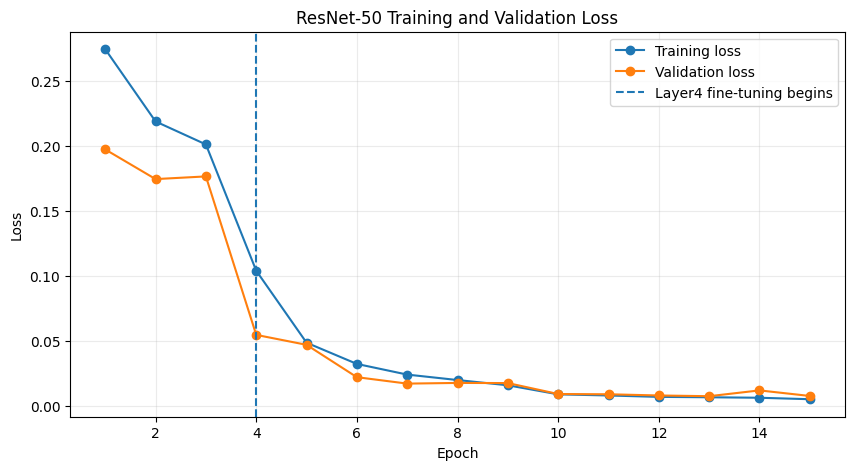

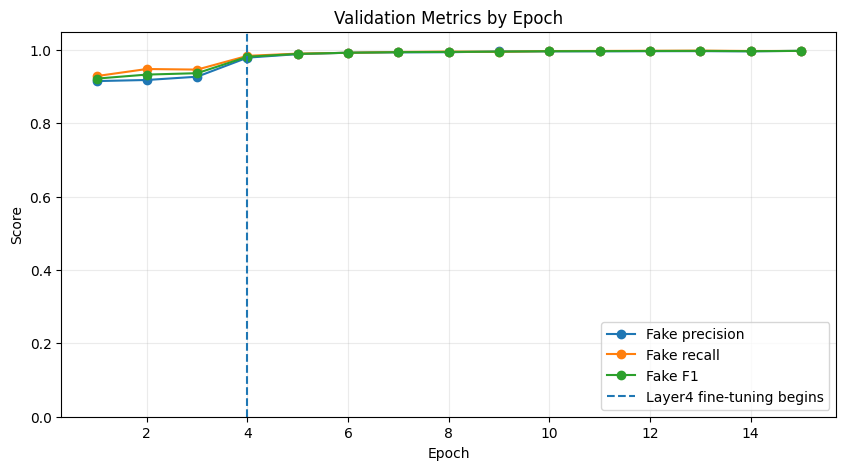

In [ ]:
if resnet50_training_history.empty:
    raise ValueError("Training history is empty.")

first_fine_tune_epoch = HEAD_ONLY_EPOCHS + 1

plt.figure(figsize=(10, 5))
plt.plot(
    resnet50_training_history["Epoch"],
    resnet50_training_history["Train loss"],
    marker="o",
    label="Training loss",
)
plt.plot(
    resnet50_training_history["Epoch"],
    resnet50_training_history["Val loss"],
    marker="o",
    label="Validation loss",
)
plt.axvline(
    first_fine_tune_epoch,
    linestyle="--",
    label="Layer4 fine-tuning begins",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    resnet50_training_history["Epoch"],
    resnet50_training_history["Fake precision"],
    marker="o",
    label="Fake precision",
)
plt.plot(
    resnet50_training_history["Epoch"],
    resnet50_training_history["Fake recall"],
    marker="o",
    label="Fake recall",
)
plt.plot(
    resnet50_training_history["Epoch"],
    resnet50_training_history["Fake F1"],
    marker="o",
    label="Fake F1",
)
plt.axvline(
    first_fine_tune_epoch,
    linestyle="--",
    label="Layer4 fine-tuning begins",
)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0.0, 1.05)
plt.title("Validation Metrics by Epoch")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 13. Reload and evaluate the best validation checkpoint

This section reloads the saved best checkpoint before evaluation. Reloading ensures that the reported validation results come from the persisted best model rather than whichever epoch was run most recently in memory.

The notebook then evaluates the model on the validation set using the checkpoint’s saved decision threshold, computes metrics, and saves both the summary metrics and raw probabilities. These saved artifacts allow validation performance and plots to be reproduced later without rerunning training.

--- Best Checkpoint Validation Performance ---


,Experiment,Evaluation split,Images,Accuracy,Fake precision,Fake recall,Fake F1,Real F1,Macro F1,Weighted F1,Decision threshold,ROC-AUC,PR-AUC,Loss,Checkpoint SHA256
0,Best validation checkpoint (epoch 13),Validation,20000,0.9977,0.997,0.9984,0.9977,0.9977,0.9977,0.9977,0.51,0.9999,0.9999,0.0077,d9a7fd6a692c942b550f9848500dc3ffb10d5809cb0d00...


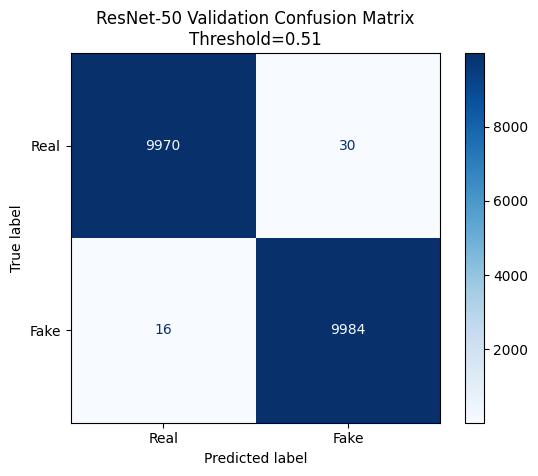

Validation metrics saved to: /content/drive/MyDrive/deepfake_detection_checkpoints/resnet50_validation_metrics.csv
Validation probabilities saved to: /content/drive/MyDrive/deepfake_detection_checkpoints/resnet50_validation_predictions.npz


In [ ]:
best_checkpoint = load_trusted_checkpoint(
    CHECKPOINT_PATH,
    DEVICE,
)

resnet50_transfer_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)
resnet50_transfer_model.eval()

BEST_VAL_THRESHOLD = float(
    best_checkpoint["decision_threshold"]
)
CHECKPOINT_SHA256 = file_sha256(CHECKPOINT_PATH)

(
    final_validation_loss,
    final_targets,
    final_probabilities,
) = run_evaluation_epoch(
    resnet50_transfer_model,
    resnet50_valid_loader,
    resnet50_loss_function,
    device=DEVICE,
)

final_predictions = (
    final_probabilities >= BEST_VAL_THRESHOLD
).astype(np.int64)

val_metrics = calculate_classification_metrics(
    experiment_name=(
        f"Best validation checkpoint "
        f"(epoch {best_checkpoint['epoch']})"
    ),
    evaluation_split="Validation",
    true_targets=final_targets,
    predicted_targets=final_predictions,
    predicted_probabilities=final_probabilities,
    threshold=BEST_VAL_THRESHOLD,
)
val_metrics["Loss"] = float(final_validation_loss)
val_metrics["Checkpoint SHA256"] = CHECKPOINT_SHA256

pd.DataFrame([val_metrics]).to_csv(
    VALIDATION_METRICS_PATH,
    index=False,
)
np.savez_compressed(
    VALIDATION_PREDICTIONS_PATH,
    true_targets=final_targets,
    fake_probabilities=final_probabilities,
    predicted_targets=final_predictions,
    decision_threshold=np.array(
        [BEST_VAL_THRESHOLD],
        dtype=np.float64,
    ),
)

print("--- Best Checkpoint Validation Performance ---")
display(pd.DataFrame([val_metrics]).round(4))

ConfusionMatrixDisplay.from_predictions(
    final_targets,
    final_predictions,
    display_labels=CLASS_NAMES,
    cmap="Blues",
)
plt.title(
    "ResNet-50 Validation Confusion Matrix\n"
    f"Threshold={BEST_VAL_THRESHOLD:.2f}"
)
plt.show()

print(f"Validation metrics saved to: {VALIDATION_METRICS_PATH}")
print(
    "Validation probabilities saved to: "
    f"{VALIDATION_PREDICTIONS_PATH}"
)

## 14. Optional locked final-test evaluation

This section runs the final evaluation on the official test split, but only when `RUN_TEST_EVALUATION = True`. During development, this flag should stay `False` so the test set remains unused until the final model and threshold have been selected.

When enabled, the test evaluation:

1. uses the full official test split,
2. applies the decision threshold saved from validation,
3. saves test metrics and predicted probabilities,
4. records the checkpoint SHA-256 fingerprint alongside the test result,
5. refuses to reuse test artifacts created by a different checkpoint.

No threshold search or model selection is performed on test data. If a new checkpoint is selected and the test results must be updated, `FORCE_RERUN_TEST = True` is required to replace the existing test artifacts.

Running the locked final test with the validation-selected threshold.
Test metrics saved to: /content/drive/MyDrive/deepfake_detection_checkpoints/resnet50_final_test_metrics.csv
Test probabilities saved to: /content/drive/MyDrive/deepfake_detection_checkpoints/resnet50_final_test_predictions.npz


,Experiment,Evaluation split,Images,Accuracy,Fake precision,Fake recall,Fake F1,Real F1,Macro F1,Weighted F1,Decision threshold,ROC-AUC,PR-AUC,Loss,Checkpoint SHA256
0,Best validation checkpoint (epoch 13),Validation,20000,0.9977,0.9970,0.9984,0.9977,0.9977,0.9977,0.9977,0.51,0.9999,0.9999,0.0077,d9a7fd6a692c942b550f9848500dc3ffb10d5809cb0d00...
1,Locked final test,Test,20000,0.9969,0.9961,0.9977,0.9969,0.9969,0.9969,0.9969,0.51,1.0000,1.0000,0.0088,d9a7fd6a692c942b550f9848500dc3ffb10d5809cb0d00...


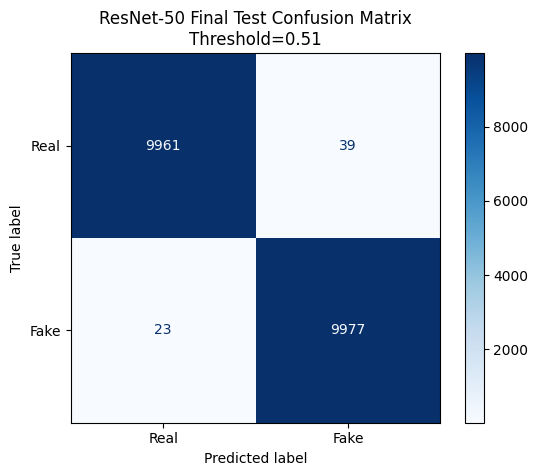

In [ ]:
test_metrics = None
test_targets_arr = None
test_probs_arr = None
test_preds_arr = None

saved_test_artifacts_exist = (
    TEST_METRICS_PATH.exists()
    and TEST_PREDICTIONS_PATH.exists()
)

saved_test_matches_checkpoint = False
saved_test_metrics_frame = None

if saved_test_artifacts_exist:
    saved_test_metrics_frame = pd.read_csv(TEST_METRICS_PATH)
    if saved_test_metrics_frame.empty:
        raise ValueError(
            f"Saved test metrics file is empty: {TEST_METRICS_PATH}"
        )

    saved_test_checkpoint_hash = str(
        saved_test_metrics_frame.iloc[0].get(
            "Checkpoint SHA256",
            "",
        )
    )
    saved_test_matches_checkpoint = (
        saved_test_checkpoint_hash == CHECKPOINT_SHA256
    )

if RUN_TEST_EVALUATION:
    if (
        saved_test_artifacts_exist
        and saved_test_matches_checkpoint
        and not FORCE_RERUN_TEST
    ):
        print(
            "Saved final-test artifacts match the current checkpoint. "
            "Loading them without rerunning inference."
        )

        test_metrics = (
            saved_test_metrics_frame
            .iloc[0]
            .to_dict()
        )
        saved_test_predictions = np.load(
            TEST_PREDICTIONS_PATH
        )
        test_targets_arr = saved_test_predictions[
            "true_targets"
        ]
        test_probs_arr = saved_test_predictions[
            "fake_probabilities"
        ]
        test_preds_arr = saved_test_predictions[
            "predicted_targets"
        ]

    elif (
        saved_test_artifacts_exist
        and not saved_test_matches_checkpoint
        and not FORCE_RERUN_TEST
    ):
        raise RuntimeError(
            "Saved final-test artifacts belong to a different checkpoint. "
            "Do not reuse them for the current model. Set "
            "FORCE_RERUN_TEST=True only when the current model is final and "
            "a replacement test evaluation is methodologically justified."
        )

    else:
        print(
            "Running the locked final test with the "
            "validation-selected threshold."
        )

        test_paths = test_real_paths + test_fake_paths
        test_targets = np.array(
            [REAL_LABEL] * len(test_real_paths)
            + [FAKE_LABEL] * len(test_fake_paths),
            dtype=np.int64,
        )

        resnet50_test_dataset = FacePathDataset(
            image_paths=test_paths,
            numeric_targets=test_targets,
            image_transform=evaluation_transform,
        )
        resnet50_test_loader = create_seeded_data_loader(
            resnet50_test_dataset,
            shuffle=False,
            seed=SEED,
        )

        (
            final_test_loss,
            test_targets_arr,
            test_probs_arr,
        ) = run_evaluation_epoch(
            resnet50_transfer_model,
            resnet50_test_loader,
            resnet50_loss_function,
            device=DEVICE,
        )

        saved_threshold = float(
            best_checkpoint["decision_threshold"]
        )
        test_preds_arr = (
            test_probs_arr >= saved_threshold
        ).astype(np.int64)

        test_metrics = calculate_classification_metrics(
            experiment_name="Locked final test",
            evaluation_split="Test",
            true_targets=test_targets_arr,
            predicted_targets=test_preds_arr,
            predicted_probabilities=test_probs_arr,
            threshold=saved_threshold,
        )
        test_metrics["Loss"] = float(final_test_loss)
        test_metrics["Checkpoint SHA256"] = CHECKPOINT_SHA256

        pd.DataFrame([test_metrics]).to_csv(
            TEST_METRICS_PATH,
            index=False,
        )
        np.savez_compressed(
            TEST_PREDICTIONS_PATH,
            true_targets=test_targets_arr,
            fake_probabilities=test_probs_arr,
            predicted_targets=test_preds_arr,
            decision_threshold=np.array(
                [saved_threshold],
                dtype=np.float64,
            ),
        )

        print(f"Test metrics saved to: {TEST_METRICS_PATH}")
        print(
            "Test probabilities saved to: "
            f"{TEST_PREDICTIONS_PATH}"
        )

elif saved_test_artifacts_exist and saved_test_matches_checkpoint:
    print(
        "Final-test inference is disabled. Existing test artifacts match "
        "the current checkpoint and will be loaded for reporting only."
    )
    test_metrics = (
        saved_test_metrics_frame
        .iloc[0]
        .to_dict()
    )
    saved_test_predictions = np.load(
        TEST_PREDICTIONS_PATH
    )
    test_targets_arr = saved_test_predictions[
        "true_targets"
    ]
    test_probs_arr = saved_test_predictions[
        "fake_probabilities"
    ]
    test_preds_arr = saved_test_predictions[
        "predicted_targets"
    ]

elif saved_test_artifacts_exist:
    print(
        "Final-test inference is disabled. Existing test artifacts were "
        "not loaded because they belong to a different checkpoint."
    )

else:
    print(
        "Final-test evaluation is disabled. "
        "Set RUN_TEST_EVALUATION=True only when the model is locked."
    )

if test_metrics is not None:
    comparison_report = pd.DataFrame(
        [val_metrics, test_metrics]
    )
    display(comparison_report.round(4))

    ConfusionMatrixDisplay.from_predictions(
        test_targets_arr,
        test_preds_arr,
        display_labels=CLASS_NAMES,
        cmap="Blues",
    )
    plt.title(
        "ResNet-50 Final Test Confusion Matrix\n"
        f"Threshold="
        f"{float(test_metrics['Decision threshold']):.2f}"
    )
    plt.show()

## 15. ROC and precision–recall curves

This section visualizes how well the model separates Real and Fake images using ROC and precision–recall (PR) curves. The validation curves are always shown, using the saved validation probabilities and metrics.

When saved test predictions are available, the corresponding test ROC and PR curves are added to the same plots. This makes it easy to compare validation performance to final test performance without rerunning any evaluations.

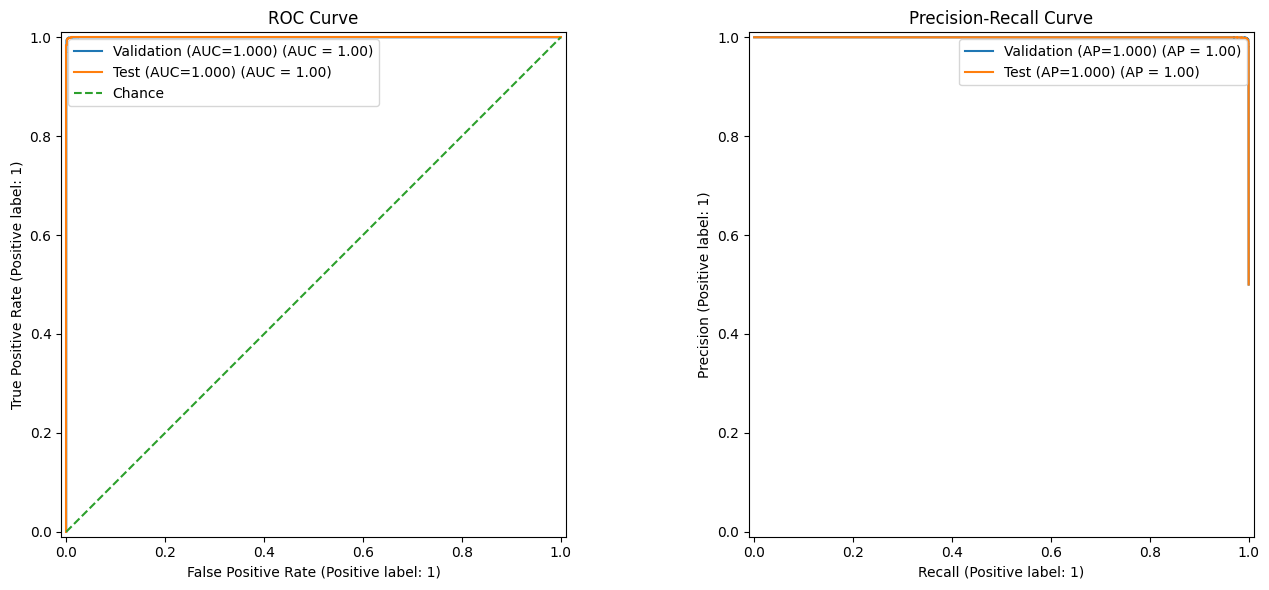

In [33]:
fig, (roc_axis, pr_axis) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

RocCurveDisplay.from_predictions(
    final_targets,
    final_probabilities,
    name=(
        "Validation "
        f"(AUC={val_metrics['ROC-AUC']:.3f})"
    ),
    ax=roc_axis,
)

PrecisionRecallDisplay.from_predictions(
    final_targets,
    final_probabilities,
    name=(
        "Validation "
        f"(AP={val_metrics['PR-AUC']:.3f})"
    ),
    ax=pr_axis,
)

if (
    test_metrics is not None
    and test_targets_arr is not None
    and test_probs_arr is not None
):
    RocCurveDisplay.from_predictions(
        test_targets_arr,
        test_probs_arr,
        name=(
            "Test "
            f"(AUC={float(test_metrics['ROC-AUC']):.3f})"
        ),
        ax=roc_axis,
    )

    PrecisionRecallDisplay.from_predictions(
        test_targets_arr,
        test_probs_arr,
        name=(
            "Test "
            f"(AP={float(test_metrics['PR-AUC']):.3f})"
        ),
        ax=pr_axis,
    )

roc_axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)
roc_axis.set_title("ROC Curve")
roc_axis.legend()

pr_axis.set_title("Precision-Recall Curve")
pr_axis.legend()

plt.tight_layout()
plt.show()

## 16. Predicted-probability distributions

This section plots histograms of the model’s predicted probabilities for Real and Fake images. The validation histogram shows how well the two classes are separated and where the locked validation decision threshold falls on the probability axis.

Validation probability distributions are always available, even when test evaluation is disabled. When saved test predictions exist, a matching histogram is shown for the test split using the same visualization, so class separation and threshold placement can be compared between validation and test.

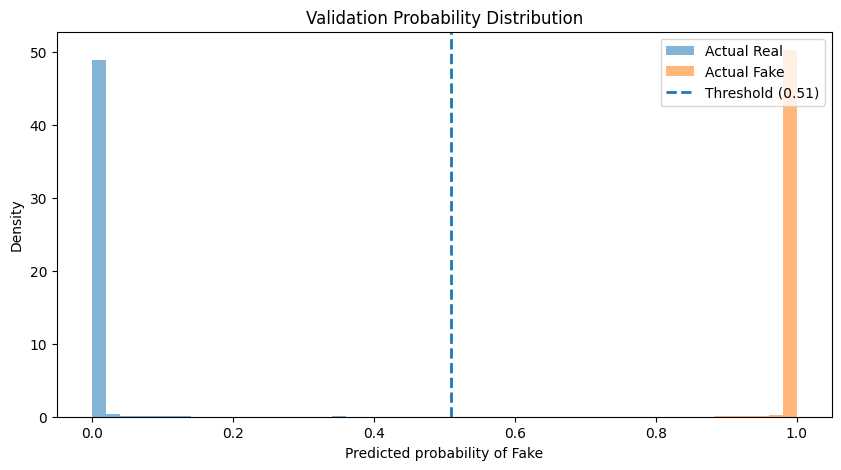

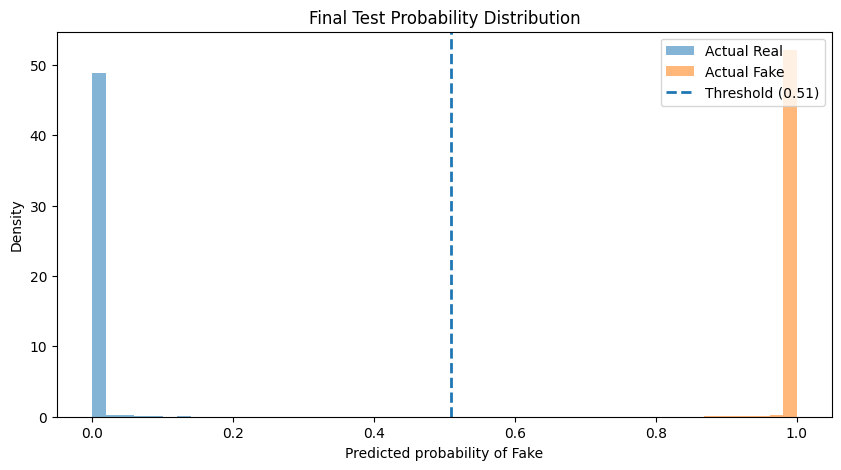

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(
    final_probabilities[final_targets == REAL_LABEL],
    bins=50,
    alpha=0.55,
    density=True,
    label="Actual Real",
)
plt.hist(
    final_probabilities[final_targets == FAKE_LABEL],
    bins=50,
    alpha=0.55,
    density=True,
    label="Actual Fake",
)
plt.axvline(
    BEST_VAL_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Threshold ({BEST_VAL_THRESHOLD:.2f})",
)
plt.xlabel("Predicted probability of Fake")
plt.ylabel("Density")
plt.title("Validation Probability Distribution")
plt.legend()
plt.show()

if (
    test_metrics is not None
    and test_targets_arr is not None
    and test_probs_arr is not None
):
    test_threshold = float(
        test_metrics["Decision threshold"]
    )

    plt.figure(figsize=(10, 5))
    plt.hist(
        test_probs_arr[test_targets_arr == REAL_LABEL],
        bins=50,
        alpha=0.55,
        density=True,
        label="Actual Real",
    )
    plt.hist(
        test_probs_arr[test_targets_arr == FAKE_LABEL],
        bins=50,
        alpha=0.55,
        density=True,
        label="Actual Fake",
    )
    plt.axvline(
        test_threshold,
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({test_threshold:.2f})",
    )
    plt.xlabel("Predicted probability of Fake")
    plt.ylabel("Density")
    plt.title("Final Test Probability Distribution")
    plt.legend()
    plt.show()

## 17. Misclassified Image Examples

This section displays examples of images that were misclassified by the model. This can help in understanding common failure modes and potential areas for improvement.

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Ensure constants are defined
if 'REAL_LABEL' not in globals():
    REAL_LABEL = 0
if 'FAKE_LABEL' not in globals():
    FAKE_LABEL = 1

# Ensure PROJECT_OUTPUT_DIRECTORY is defined. If not, default to the expected path.
if 'PROJECT_OUTPUT_DIRECTORY' not in globals():
    PROJECT_OUTPUT_DIRECTORY = Path("/content/drive/MyDrive/deepfake_detection_checkpoints")
    PROJECT_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
else:
    PROJECT_OUTPUT_DIRECTORY = Path(globals()['PROJECT_OUTPUT_DIRECTORY'])

# Use globally defined paths if available, otherwise construct them.
# This ensures we use the exact Path objects that were written to by previous cells.
if 'VALIDATION_PREDICTIONS_PATH' in globals():
    validation_predictions_path_used = globals()['VALIDATION_PREDICTIONS_PATH']
else:
    validation_predictions_path_used = PROJECT_OUTPUT_DIRECTORY / "resnet50_validation_predictions.npz"

if 'TEST_PREDICTIONS_PATH' in globals():
    test_predictions_path_used = globals()['TEST_PREDICTIONS_PATH']
else:
    test_predictions_path_used = PROJECT_OUTPUT_DIRECTORY / "resnet50_final_test_predictions.npz"

if 'SAMPLE_MANIFEST_PATH' in globals():
    sample_manifest_path_used = globals()['SAMPLE_MANIFEST_PATH']
else:
    sample_manifest_path_used = PROJECT_OUTPUT_DIRECTORY / "resnet50_sample_manifest.csv"

# Initialize variables to empty/default values for safety
final_targets = np.array([])
final_predictions = np.array([])
final_probabilities = np.array([])
BEST_VAL_THRESHOLD = 0.5
project_valid_paths = []

test_targets_arr = None
test_preds_arr = None
test_all_paths = []
RUN_TEST_EVALUATION_LOCAL = False # Default unless explicitly set below

# Attempt to load validation predictions
try:
    if validation_predictions_path_used.exists():
        saved_predictions = np.load(validation_predictions_path_used)
        final_targets = saved_predictions['true_targets']
        final_probabilities = saved_predictions['fake_probabilities']
        final_predictions = saved_predictions['predicted_targets']
        BEST_VAL_THRESHOLD = saved_predictions['decision_threshold'].item()
        print(f"Loaded final_targets, final_predictions, and BEST_VAL_THRESHOLD from {validation_predictions_path_used}")
    else:
        print(f"Warning: Validation predictions file {validation_predictions_path_used} not found. Validation misclassifications will not be displayed.")
except Exception as e:
    print(f"Error loading validation predictions from {validation_predictions_path_used}: {e}")

# Attempt to load project_valid_paths from the sample manifest
try:
    if sample_manifest_path_used.exists():
        sample_manifest_df = pd.read_csv(sample_manifest_path_used)
        project_valid_paths = sample_manifest_df[sample_manifest_df['Split'] == 'Validation']['Image path'].tolist()
        # Convert paths back to Path objects as they were likely saved as strings
        project_valid_paths = [Path(p) for p in project_valid_paths]
        print(f"Loaded project_valid_paths from {sample_manifest_path_used}")
    else:
        print(f"Warning: Sample manifest file {sample_manifest_path_used} not found. project_valid_paths could not be loaded. Validation misclassified images may not be displayed.")
except Exception as e:
    print(f"Error loading project_valid_paths from manifest {sample_manifest_path_used}: {e}")

# Get RUN_TEST_EVALUATION from globals if available
if 'RUN_TEST_EVALUATION' in globals():
    RUN_TEST_EVALUATION_LOCAL = globals()['RUN_TEST_EVALUATION']

# Attempt to load test variables if RUN_TEST_EVALUATION is true
if RUN_TEST_EVALUATION_LOCAL:
    try:
        if test_predictions_path_used.exists():
            saved_test_predictions = np.load(test_predictions_path_used)
            test_targets_arr = saved_test_predictions['true_targets']
            test_probs_arr = saved_test_predictions['fake_probabilities']
            test_preds_arr = saved_test_predictions['predicted_targets']
            # test_threshold might not be strictly needed for display, but keep for consistency
            test_threshold = saved_test_predictions['decision_threshold'].item()
            print(f"Loaded test_targets_arr, test_preds_arr from {test_predictions_path_used}")

            # Reconstruct test_all_paths if not available in globals
            if 'test_real_paths' in globals() and 'test_fake_paths' in globals():
                # These are already Path objects from earlier cells
                test_all_paths = globals()['test_real_paths'] + globals()['test_fake_paths']
            else:
                print("Warning: test_real_paths or test_fake_paths not found in globals. Test misclassified images may not be fully displayed.")
                test_all_paths = [] # Initialize as empty if not found
        else:
            print(f"Warning: Test predictions file {test_predictions_path_used} not found. Test misclassifications will not be displayed.")
    except Exception as e:
        print(f"Error loading test predictions: {e}")
else: # RUN_TEST_EVALUATION is False or not globally defined
    print("Test evaluation is not enabled (RUN_TEST_EVALUATION is False or not defined).")

def display_image_grid(image_paths, titles, category_title, num_images_to_display=None):
    """Displays a grid of images."""
    if not image_paths:
        print(f"No images to display for {category_title}.")
        return

    num_images = len(image_paths)
    if num_images_to_display is not None:
        num_images = min(num_images, num_images_to_display)

    # Determine number of rows and columns for the grid
    cols = 5 # Fixed number of columns
    rows = (num_images + cols - 1) // cols

    fig = plt.figure(figsize=(18, rows * 4)) # Adjust figure size dynamically
    fig.suptitle(category_title, fontsize=16, y=1.02)

    for i in range(num_images):
        ax = fig.add_subplot(rows, cols, i + 1)
        try:
            img = Image.open(image_paths[i])
            ax.imshow(img)
            ax.set_title(titles[i], fontsize=10)
            ax.axis("off")
        except Exception as e:
            print(f"Could not load image {image_paths[i]}: {e}")
            ax.set_title(f"Error loading image", fontsize=10)
            ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
    plt.show()

print("--- Validation Misclassifications ---")

# Misclassified real images (predicted as fake) on validation set
if final_targets.size > 0 and final_predictions.size > 0 and project_valid_paths:
    valid_real_fakes_indices = np.where((final_targets == REAL_LABEL) & (final_predictions == FAKE_LABEL))[0]
    valid_real_fakes_paths = [project_valid_paths[i] for i in valid_real_fakes_indices]
    valid_real_fakes_titles = [f"Real (Pred: Fake)" for _ in valid_real_fakes_paths]
    display_image_grid(
        valid_real_fakes_paths,
        valid_real_fakes_titles,
        "Validation: Actual Real Classified as Fake",
        num_images_to_display=None
    )
else:
    print("Validation misclassifications not available (data not loaded or empty).")

# Misclassified fake images (predicted as real) on validation set
if final_targets.size > 0 and final_predictions.size > 0 and project_valid_paths:
    valid_fake_reals_indices = np.where((final_targets == FAKE_LABEL) & (final_predictions == REAL_LABEL))[0]
    valid_fake_reals_paths = [project_valid_paths[i] for i in valid_fake_reals_indices]
    valid_fake_reals_titles = [f"Fake (Pred: Real)" for _ in valid_fake_reals_paths]
    display_image_grid(
        valid_fake_reals_paths,
        valid_fake_reals_titles,
        "Validation: Actual Fake Classified as Real",
        num_images_to_display=None
    )
else:
    print("Validation misclassifications not available (data not loaded or empty).")

# --- Test Misclassifications (conditional) ---
if (RUN_TEST_EVALUATION_LOCAL and test_targets_arr is not None and
    test_preds_arr is not None and len(test_all_paths) > 0):
    print("\n--- Test Misclassifications ---")

    # Misclassified real images (predicted as fake) on test set
    test_real_fakes_indices = np.where((test_targets_arr == REAL_LABEL) & (test_preds_arr == FAKE_LABEL))[0]
    test_real_fakes_paths = [test_all_paths[i] for i in test_real_fakes_indices]
    test_real_fakes_titles = [f"Real (Pred: Fake)" for _ in test_real_fakes_paths]
    display_image_grid(
        test_real_fakes_paths,
        test_real_fakes_titles,
        "Test: Actual Real Classified as Fake",
        num_images_to_display=None
    )

    # Misclassified fake images (predicted as real) on test set
    test_fake_reals_indices = np.where((test_targets_arr == FAKE_LABEL) & (test_preds_arr == REAL_LABEL))[0]
    test_fake_reals_paths = [test_all_paths[i] for i in test_fake_reals_indices]
    test_fake_reals_titles = [f"Fake (Pred: Real)" for _ in test_fake_reals_paths]
    display_image_grid(
        test_fake_reals_paths,
        test_fake_reals_titles,
        "Test: Actual Fake Classified as Real",
        num_images_to_display=None
    )
else:
    print("Test misclassifications not available (Test evaluation not enabled, or data not loaded/empty).")

## 18. Save Misclassified Images to Google Drive

This section saves all identified misclassified images into organized subfolders within the main project output directory on Google Drive. This allows for further inspection and analysis of the model's errors.

In [36]:
import shutil

def save_misclassified_images(image_paths, destination_folder_name):
    """Saves a list of image paths to a specified destination folder."""
    if not image_paths:
        print(f"No images to save for {destination_folder_name}.")
        return

    destination_path = PROJECT_OUTPUT_DIRECTORY / destination_folder_name
    destination_path.mkdir(parents=True, exist_ok=True)

    print(f"Saving {len(image_paths)} images to {destination_path}...")
    for img_path in image_paths:
        try:
            shutil.copy(img_path, destination_path / img_path.name)
        except Exception as e:
            print(f"Could not copy {img_path}: {e}")
    print(f"Finished saving images to {destination_path}.")

# --- Save Validation Misclassifications ---
print("\n--- Saving Validation Misclassifications ---")
if final_targets.size > 0 and final_predictions.size > 0 and project_valid_paths:
    # Misclassified real images (predicted as fake) on validation set
    valid_real_fakes_indices = np.where((final_targets == REAL_LABEL) & (final_predictions == FAKE_LABEL))[0]
    valid_real_fakes_paths = [project_valid_paths[i] for i in valid_real_fakes_indices]
    save_misclassified_images(valid_real_fakes_paths, "validation_real_fakes")

    # Misclassified fake images (predicted as real) on validation set
    valid_fake_reals_indices = np.where((final_targets == FAKE_LABEL) & (final_predictions == REAL_LABEL))[0]
    valid_fake_reals_paths = [project_valid_paths[i] for i in valid_fake_reals_indices]
    save_misclassified_images(valid_fake_reals_paths, "validation_fake_reals")
else:
    print("Validation misclassifications data not available for saving.")

# --- Save Test Misclassifications (conditional) ---
print("\n--- Saving Test Misclassifications ---")
if (RUN_TEST_EVALUATION_LOCAL and test_targets_arr is not None and
    test_preds_arr is not None and len(test_all_paths) > 0):
    # Misclassified real images (predicted as fake) on test set
    test_real_fakes_indices = np.where((test_targets_arr == REAL_LABEL) & (test_preds_arr == FAKE_LABEL))[0]
    test_real_fakes_paths = [test_all_paths[i] for i in test_real_fakes_indices]
    save_misclassified_images(test_real_fakes_paths, "test_real_fakes")

    # Misclassified fake images (predicted as real) on test set
    test_fake_reals_indices = np.where((test_targets_arr == FAKE_LABEL) & (test_preds_arr == REAL_LABEL))[0]
    test_fake_reals_paths = [test_all_paths[i] for i in test_fake_reals_indices]
    save_misclassified_images(test_fake_reals_paths, "test_fake_reals")
else:
    print("Test misclassifications data not available for saving.")


--- Saving Validation Misclassifications ---
Saving 30 images to /content/drive/MyDrive/deepfake_detection_checkpoints/validation_real_fakes...
Finished saving images to /content/drive/MyDrive/deepfake_detection_checkpoints/validation_real_fakes.
Saving 16 images to /content/drive/MyDrive/deepfake_detection_checkpoints/validation_fake_reals...
Finished saving images to /content/drive/MyDrive/deepfake_detection_checkpoints/validation_fake_reals.

--- Saving Test Misclassifications ---
Saving 39 images to /content/drive/MyDrive/deepfake_detection_checkpoints/test_real_fakes...
Finished saving images to /content/drive/MyDrive/deepfake_detection_checkpoints/test_real_fakes.
Saving 23 images to /content/drive/MyDrive/deepfake_detection_checkpoints/test_fake_reals...
Finished saving images to /content/drive/MyDrive/deepfake_detection_checkpoints/test_fake_reals.


## 17. Saved-artifact summary

This final section lists the files produced by the notebook and confirms which outputs were successfully saved. It includes the main training artifacts, validation artifacts, and any final test artifacts that were created during the run.

It also reports the key checkpoint metadata, including the best epoch, the training stage at which the best checkpoint was selected, the metric used for model selection, the best recorded value of that metric, and the saved decision threshold. This makes it easy to verify exactly which model and settings produced the final reported results.

In [37]:
artifact_rows = [
    {
        "Artifact": "Best checkpoint",
        "Path": str(CHECKPOINT_PATH),
        "Exists": CHECKPOINT_PATH.exists(),
    },
    {
        "Artifact": "Training history",
        "Path": str(HISTORY_PATH),
        "Exists": HISTORY_PATH.exists(),
    },
    {
        "Artifact": "Sample manifest",
        "Path": str(SAMPLE_MANIFEST_PATH),
        "Exists": SAMPLE_MANIFEST_PATH.exists(),
    },
    {
        "Artifact": "Validation metrics",
        "Path": str(VALIDATION_METRICS_PATH),
        "Exists": VALIDATION_METRICS_PATH.exists(),
    },
    {
        "Artifact": "Validation predictions",
        "Path": str(VALIDATION_PREDICTIONS_PATH),
        "Exists": VALIDATION_PREDICTIONS_PATH.exists(),
    },
    {
        "Artifact": "Final test metrics",
        "Path": str(TEST_METRICS_PATH),
        "Exists": TEST_METRICS_PATH.exists(),
    },
    {
        "Artifact": "Final test predictions",
        "Path": str(TEST_PREDICTIONS_PATH),
        "Exists": TEST_PREDICTIONS_PATH.exists(),
    },
]

display(pd.DataFrame(artifact_rows))

checkpoint_summary = {
    "Best epoch": int(best_checkpoint["epoch"]),
    "Training stage": best_checkpoint.get(
        "training_stage",
        "Not recorded in checkpoint",
    ),
    "Monitor metric": best_checkpoint.get(
        "monitor_metric",
        "Not recorded",
    ),
    "Monitor value": float(best_checkpoint["monitor_value"]),
    "Decision threshold": float(
        best_checkpoint["decision_threshold"]
    ),
}
display(pd.DataFrame([checkpoint_summary]).round(4))

,Artifact,Path,Exists
0,Best checkpoint,/content/drive/MyDrive/deepfake_detection_chec...,True
1,Training history,/content/drive/MyDrive/deepfake_detection_chec...,True
2,Sample manifest,/content/drive/MyDrive/deepfake_detection_chec...,True
3,Validation metrics,/content/drive/MyDrive/deepfake_detection_chec...,True
4,Validation predictions,/content/drive/MyDrive/deepfake_detection_chec...,True
5,Final test metrics,/content/drive/MyDrive/deepfake_detection_chec...,True
6,Final test predictions,/content/drive/MyDrive/deepfake_detection_chec...,True


,Best epoch,Training stage,Monitor metric,Monitor value,Decision threshold
0,13,Layer4 fine-tuning,Fake F1,0.9977,0.51
